In [1]:
import os
import sys
from torchdiffeq import odeint as odeint

sys.path.append("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors
from mpl_toolkits import mplot3d
from numpy import linalg as la
from scipy import stats
from scipy import spatial as sp
from scipy import integrate as integ
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from ipywidgets import interact, IntSlider
import types
import lyapynov as lya 

import multiprocessing as mp

import models.DynamicalSystems_new as ds

import models.Neural_ODEs_v2 as nodes

# Set up Models

In [2]:
device = torch.device('cpu')

In [3]:
t_pts = torch.arange(0, 500, 0.01).to(device)

In [4]:

os.chdir("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes/NODE_Dynamic_Bifurcation_Parameter")



model_sn = torch.load('networks/SaddleNode_driven_neural_ODE_m2.pt', weights_only=False).to(device)


node_sn = nodes.Neural_DynamicalSystem(model=model_sn)
sn_analysis_node = ds.DynamicalSystems_analysis(node_sn)

node_sn.model.drdt = 0.001
sn_analysis_node.model.model.dadt = 0.001

In [ ]:

true_sn = ds.saddlenode()
true_sn.f = true_sn.na_f
true_sn.dadt = 0.001
sn_analysis_true = ds.DynamicalSystems_analysis(true_sn)




true_le = lambda a: -2 * torch.sqrt(-a)
a_func = lambda t : true_sn.dadt * t - 0.5



In [14]:
sn_analysis_true.model.dadt

0.001

In [40]:
list_pts = []
drdt_pts = torch.arange(0.001, 0.011, 0.001)

a_func = lambda t, r = sn_analysis_true.model.dadt: r * t - 0.5

In [43]:
for drdt in drdt_pts:
    sn_analysis_true.model.dadt = drdt
    traj = true_sn.solve(x0=torch.tensor([-0.25, -0.5]), t_span=(0, int(0.5/sn_analysis_true.model.dadt)), dt=0.01)

    pertubation_vectors = torch.eye(2, dtype=torch.float32)[:, 0:1].repeat(traj.shape[0], 1, 1)
    input = torch.cat([pertubation_vectors, traj.unsqueeze(2)], dim=2)

    jac_r = sn_analysis_true.variational_f(t=0, x=input)[:, :, 0:2]
    list_pts.append(jac_r)

In [41]:
true_list_pts = []
for drdt in drdt_pts:
    sn_analysis_true.model.dadt = drdt
    true_le_pts = true_le(a_func(t_pts, r=drdt))
    true_list_pts.append(true_le_pts)


In [47]:
true_list_pts

[tensor([-1.4142, -1.4142, -1.4142,  ..., -1.3417, -1.3417, -1.3417]),
 tensor([-1.4142, -1.4142, -1.4142,  ..., -1.2650, -1.2650, -1.2649]),
 tensor([-1.4142, -1.4142, -1.4141,  ..., -1.1834, -1.1833, -1.1833]),
 tensor([-1.4142, -1.4142, -1.4141,  ..., -1.0957, -1.0956, -1.0955]),
 tensor([-1.4142, -1.4141, -1.4141,  ..., -1.0003, -1.0002, -1.0001]),
 tensor([-1.4142, -1.4141, -1.4140,  ..., -0.8948, -0.8947, -0.8946]),
 tensor([-1.4142, -1.4141, -1.4140,  ..., -0.7751, -0.7750, -0.7748]),
 tensor([-1.4142, -1.4141, -1.4140,  ..., -0.6332, -0.6330, -0.6327]),
 tensor([-1.4142, -1.4141, -1.4140,  ..., -0.4484, -0.4480, -0.4476]),
 tensor([-1.4142, -1.4141, -1.4139,  ..., -0.0346, -0.0283, -0.0200])]

In [51]:
true_list_pts[0].shape

torch.Size([5000])

ValueError: x and y must have same first dimension, but have shapes (50000,) and (49900, 2, 2)

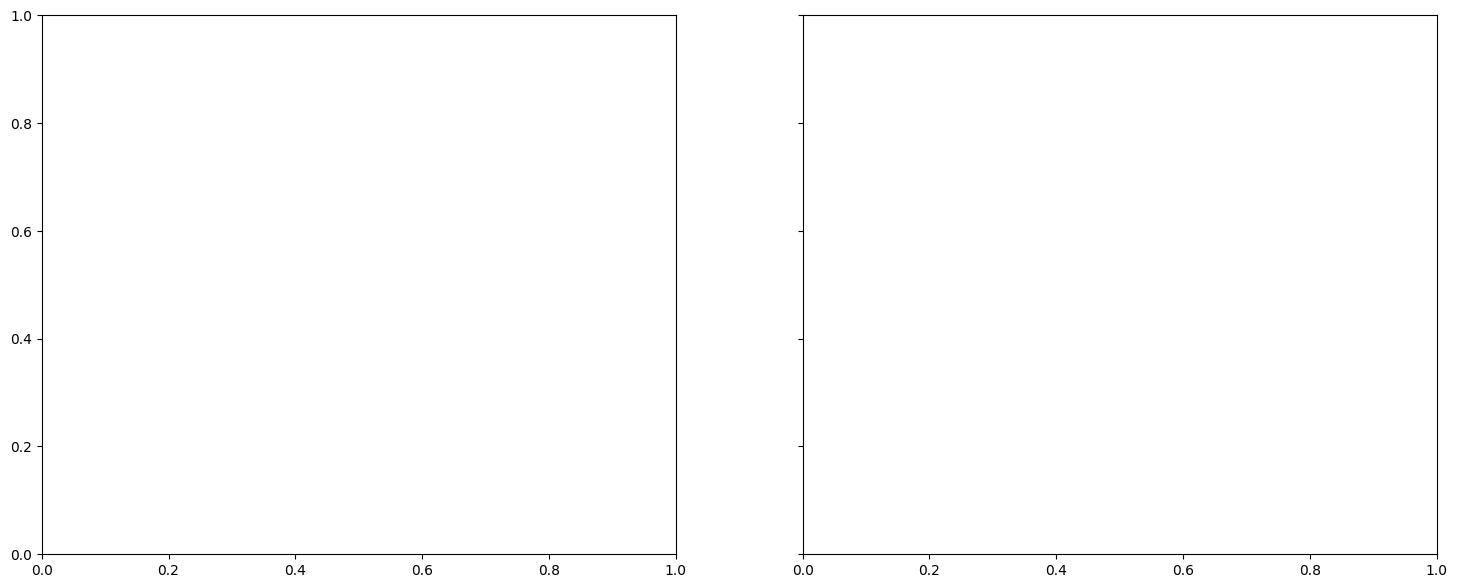

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)



# Left plot - FTLE vs time

# Right plot - FTLE vs bifurcation parameter a


drdt = 0.001
t_pts = torch.arange(0, int(0.5/drdt), 0.01).to(device)

axes[0].plot(a_func(t_pts, r=drdt), list_pts[0].detach().cpu(), linestyle='-', marker='', markersize=2, label='Frozen LE')

axes[0].plot(a_func(t_pts, r=drdt), true_list_pts[0].detach().cpu(), linestyle='-', marker='', markersize=2, label='True LE')

axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$r$ (bifurcation parameter). dr/dt = 0.001')
axes[0].grid(True, alpha=0.3)

axes[0].legend()

In [21]:
sn_analysis_true.model.dadt = 0.01
traj = true_sn.solve(x0=torch.tensor([-0.25, -0.5]), t_span=(0, int(0.5/sn_analysis_true.model.dadt)), dt=0.01)

pertubation_vectors = torch.eye(2, dtype=torch.float32)[:, 0:1].repeat(traj.shape[0], 1, 1)
input = torch.cat([pertubation_vectors, traj.unsqueeze(2)], dim=2)

jac_r_01 = sn_analysis_true.variational_f(t=0, x=input)[:, :, 0:2]

In [22]:
sn_analysis_true.model.dadt = 0.1
traj = true_sn.solve(x0=torch.tensor([-0.25, -0.5]), t_span=(0, int(0.5/sn_analysis_true.model.dadt)), dt=0.01)

pertubation_vectors = torch.eye(2, dtype=torch.float32)[:, 0:1].repeat(traj.shape[0], 1, 1)
input = torch.cat([pertubation_vectors, traj.unsqueeze(2)], dim=2)

jac_r_1 = sn_analysis_true.variational_f(t=0, x=input)[:, :, 0:2]

In [25]:
a_func = lambda t, r = sn_analysis_true.model.dadt: r * t - 0.5

In [34]:
jac_r_01[:, 0, 0].detach().cpu() - true_le(a_func(t_pts, r=drdt))

tensor([ 0.9142,  0.9053,  0.8965,  ..., -0.2809, -0.2867, -0.2945])

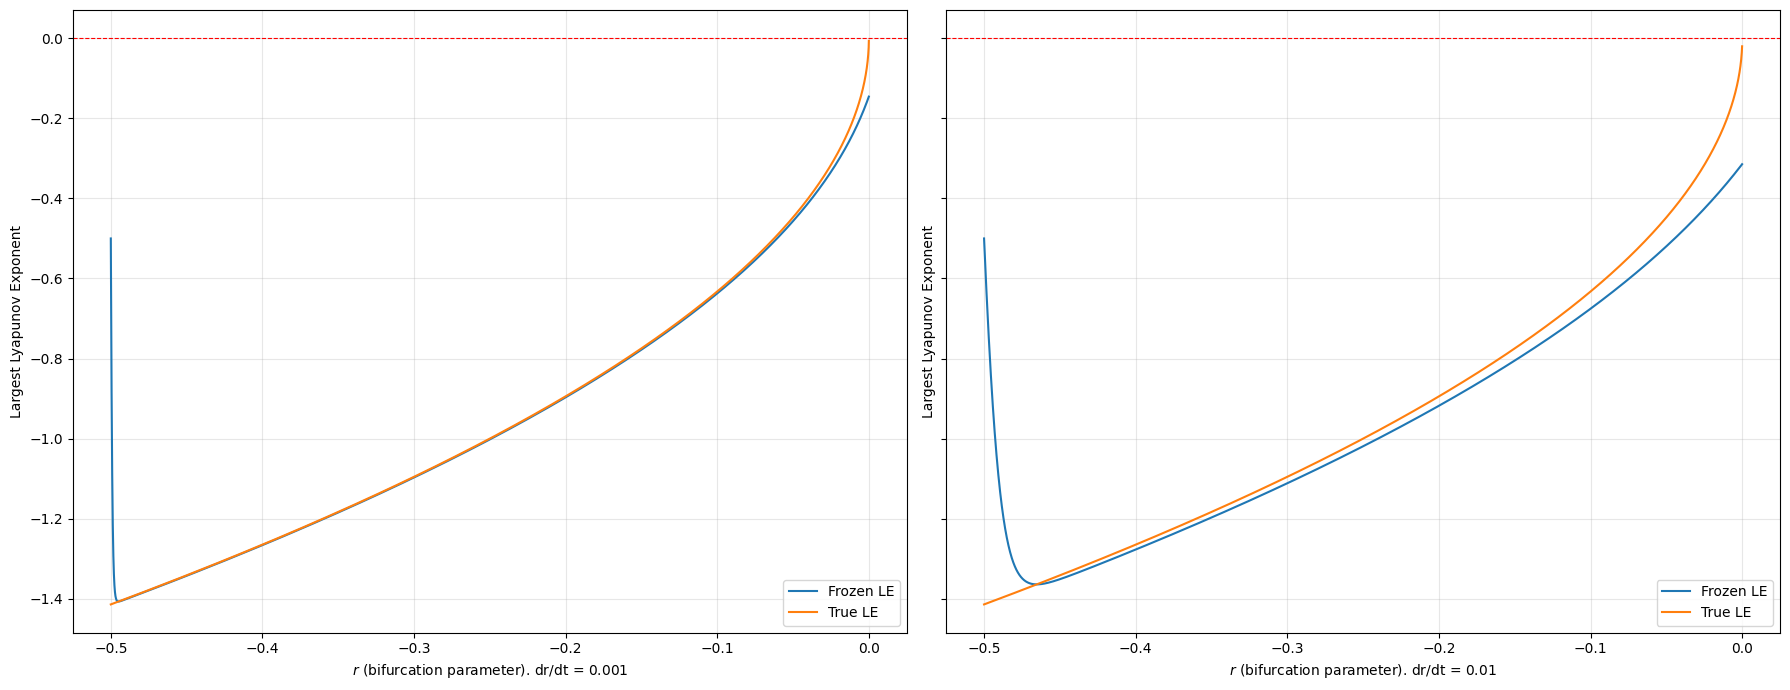

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)



# Left plot - FTLE vs time

# Right plot - FTLE vs bifurcation parameter a


drdt = 0.001
t_pts = torch.arange(0, int(0.5/drdt), 0.01).to(device)

axes[0].plot(a_func(t_pts, r=drdt), jac_r_001[:, 0, 0].detach().cpu(), linestyle='-', marker='', markersize=2, label='Frozen LE')

axes[0].plot(a_func(t_pts, r=drdt), true_le(a_func(t_pts, r=drdt)), linestyle='-', marker='', markersize=2, label='True LE')

axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$r$ (bifurcation parameter). dr/dt = 0.001')
axes[0].grid(True, alpha=0.3)

axes[0].legend()


# Right plot - FTLE vs bifurcation parameter a
drdt = 0.01
t_pts = torch.arange(0, int(0.5/drdt), 0.01).to(device)

axes[1].plot(a_func(t_pts, r=drdt), jac_r_01[:, 0, 0].detach().cpu(), linestyle='-', marker='', markersize=2, label='Frozen LE')

axes[1].plot(a_func(t_pts, r=drdt), true_le(a_func(t_pts, r=drdt)), linestyle='-', marker='', markersize=2, label='True LE')

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$r$ (bifurcation parameter). dr/dt = 0.01')
axes[1].grid(True, alpha=0.3)

axes[1].legend()


plt.tight_layout()
plt.show()

In [ ]:
traj.shape

In [37]:
true_sn.jacobian(t=0, x=traj)[:, :, 0, :]

tensor([[[-0.5000,  1.0000],
         [ 0.0000,  0.0000]],

        [[ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        ...,

        [[ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[ 0.0000,  0.0000],
         [ 0.0000,  0.0000]]])